# 02 — Data Extraction and Cleaning Pipeline

Every result in this repo is only as good as its data. This notebook
documents the two data paths and demonstrates the cleaning layer.

**Path A — 2020 fundamentals + Glassdoor snapshots (static).**
In 2020 I built a ~1,100-company universe and enriched it by scraping
Morningstar (profitability, valuation, trailing returns) with Selenium +
BeautifulSoup, and recording Glassdoor's "Positive Business Outlook" per
company. The raw scraper is preserved for reference in
[`docs/archive/`](../docs/archive/) — it is deliberately *not* part of the
installable package because scraping code rots as sites change HTML, and the
analysis should not depend on it. The snapshots it produced live under
`data/` and are loaded through `quantlab.data.fundamentals`.

**Path B — daily prices via yfinance (live, cached).**
All price-based work (signals, backtests, optimization) uses adjusted daily
closes from Yahoo Finance, downloaded once per symbol and cached under
`data/prices/` so every notebook re-runs deterministically and offline.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quantlab.data import load_fundamentals_snapshot, load_prices
from quantlab.data.fundamentals import DATA_DIR, load_research_universe

plt.rcParams["figure.figsize"] = (10, 5)

## Path A: what the raw snapshots look like

The raw CSVs are genuinely messy — mixed `yes/no/1/0` flags, thousands
separators inside numbers, em-dash placeholders for missing data, duplicate
merge columns. Below: raw vs cleaned.

In [2]:
raw = pd.read_csv(DATA_DIR / "2020_12.csv")
raw[["ticker", "outlook", "use", "trust", "upward_trend", "net_income", "div_yield"]].head(8)

,ticker,outlook,use,trust,upward_trend,net_income,div_yield
0,A,79,1,0,NaN,719.0,0.62
1,AA,NaN,1,0,NaN,NaN,NaN
2,TDG,10,1,0,maybe,699.0,—
3,AAL,61,0,0,NaN,NaN,1.42
4,CSX,23,1,0,NaN,NaN,1.15
5,AAP,34,1,0,NaN,NaN,0.55
6,AME,25,1,0,NaN,NaN,0.57
7,AB,NaN,NaN,NaN,NaN,NaN,8.75


In [3]:
clean = load_fundamentals_snapshot(DATA_DIR / "2020_12.csv")
clean[["ticker", "outlook", "use", "trust", "upward_trend", "net_income", "div_yield", "net_per_emp"]].head(8)

,ticker,outlook,use,trust,upward_trend,net_income,div_yield,net_per_emp
0,A,79,1.0,0.0,NaN,719.0,0.62,43841.463415
1,AA,<NA>,1.0,0.0,NaN,<NA>,<NA>,<NA>
2,TDG,10,1.0,0.0,NaN,699.0,<NA>,<NA>
3,AAL,61,0.0,0.0,NaN,<NA>,1.42,<NA>
4,CSX,23,1.0,0.0,NaN,<NA>,1.15,<NA>
5,AAP,34,1.0,0.0,NaN,<NA>,0.55,<NA>
6,AME,25,1.0,0.0,NaN,<NA>,0.57,<NA>
7,AB,<NA>,NaN,NaN,NaN,<NA>,8.75,<NA>


The cleaning layer:

1. Drops artifact columns (`Unnamed: *`, spreadsheet leftovers).
2. Coerces scraped strings to numbers, treating `—`, `#DIV/0!`, etc. as missing.
3. Normalizes the yes/no/1/0 flag columns to `{0, 1}` (including a `"mo"` typo
   for "no" found in the source sheets).
4. Maps trend labels: `pass`/`yes` → 1, `no` → 0, `maybe`/`too early` → unknown.
5. De-duplicates tickers and derives `net_per_emp` (net income is reported in
   millions USD).

In [4]:
clean.dtypes.value_counts()

Float64    14
str         6
float64     3
Int64       2
Name: count, dtype: int64

## Merging September + December into the research universe

The September snapshot has the ESG exclusion flags, employee counts and
company size fields; December has fresher Morningstar profitability and the
trailing-return fields. `load_research_universe` outer-joins them, preferring
December values where both exist.

In [5]:
universe = load_research_universe()
print(f"{len(universe)} companies, {universe.shape[1]} fields")
coverage = universe.notna().mean().sort_values(ascending=False)
coverage.head(20).round(3)

1170 companies, 39 fields


ticker            1.000
webscrape_date    0.967
security          0.967
sector            0.936
industry          0.936
div_yield         0.915
ft_employee       0.864
three_year        0.827
peg               0.821
one_year          0.816
five_year         0.796
roe               0.756
roa               0.756
profit_margin     0.756
ten_year          0.667
fifteen_year      0.564
outlook_date      0.559
trust             0.548
use               0.535
outlook           0.532
dtype: float64

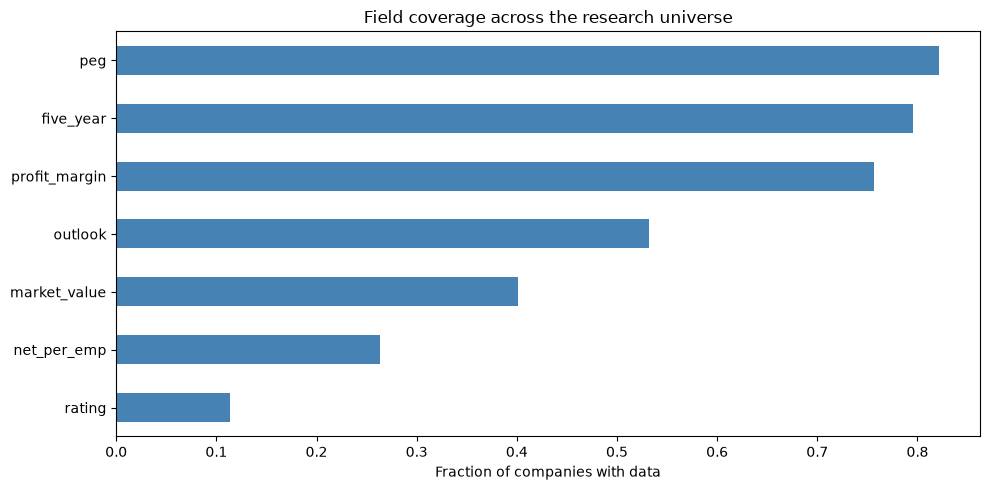

In [6]:
key_fields = ["outlook", "rating", "five_year", "peg", "profit_margin", "net_per_emp", "market_value"]
ax = coverage[key_fields].sort_values().plot.barh(color="steelblue")
ax.set_title("Field coverage across the research universe")
ax.set_xlabel("Fraction of companies with data")
plt.tight_layout()
plt.show()

## Path B: cached price loading

In [7]:
prices = load_prices(["SPY", "MSFT", "AAPL", "JPM"], "2016-01-01", "2024-12-31")
prices.tail()

,SPY,MSFT,AAPL,JPM
Date,,,,
2024-12-24,591.179077,434.179352,256.560822,233.964600
2024-12-26,591.218445,432.973633,257.375580,234.766006
2024-12-27,584.995056,425.482483,253.967377,232.863861
2024-12-30,578.319214,419.849335,250.598907,231.077591
2024-12-31,576.215271,416.558411,248.830185,231.454132


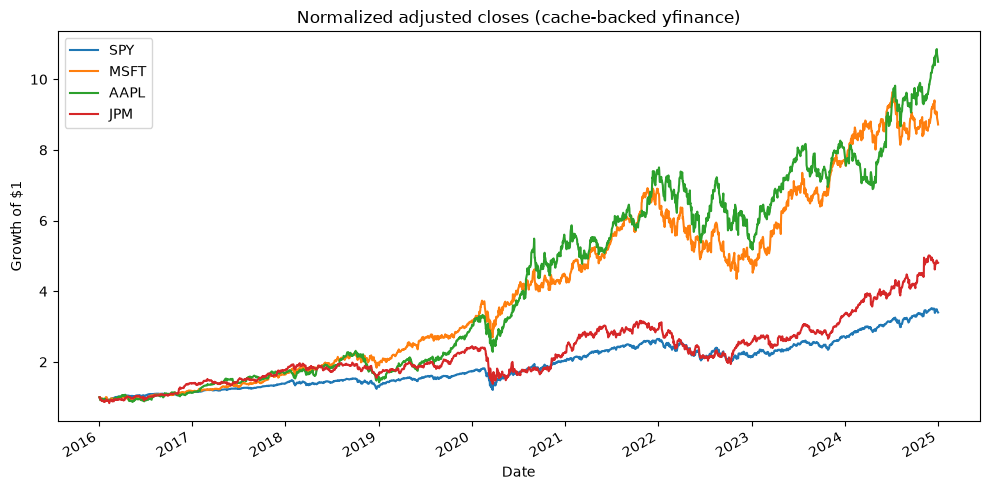

In [8]:
ax = (prices / prices.iloc[0]).plot(title="Normalized adjusted closes (cache-backed yfinance)")
ax.set_ylabel("Growth of $1")
plt.tight_layout()
plt.show()

## Takeaways

- **One canonical loading path** (`quantlab.data`) means every notebook and
  test sees identical, typed data — no per-notebook cleaning drift.
- **Static snapshots for the study, cached live data for prices** keeps the
  hypothesis work reproducible while letting the trading work stay current.
- The brittle scraping code is archived, not deleted: it documents
  provenance without being a runtime dependency.